In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.rcdefaults()
sns.set_palette(['pink'])

_Считаем данные._

_☆ **make** — марка автомобиля (BMW, Toyota и т. д.);

☆ **model** — модель автомобиля;

☆ **year** — год выпуска автомобиля;

☆ **engine_fuel_type** — тип топлива, необходимого двигателю (дизельный, электрический и т. д.);

☆ **engine_hp** — мощность двигателя в лошадиных силах;

☆ **engine_cylinders** — количество цилиндров в двигателе;

☆ **transmission_type** — тип коробки передач (автоматическая или ручная);

☆ **driven_wheels** — привод (передний, задний, полный);

☆ **number_of_doors** — количество дверей в автомобиле;

☆ **market_category** — премиальный, кроссовер и т. д.;

☆ **vehicle_size** — компактный, средний или большой;

☆ **vehicle_style** — седан или кабриолет;

☆ **highway_mpg** — миль на галлон (miles per gallon, mpg) на шоссе;

☆ **city_mpg** — миль на галлон по городу;

☆ **popularity** — количество упоминаний автомобиля в Twitter;

☆ **msrp** — рекомендованная производителем розничная цена._

In [3]:
df = pd.read_csv('data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


_Приведем все строки к одному виду._

In [4]:
#сначала все имена столбцов
#str - применяем строковую операцию
df.columns = df.columns.str.lower().str.replace(' ', '_')

#теперь столбцы со строковым значением
mask = (df.dtypes == 'str')
#их названия
str_cols = list(df.dtypes[mask].index)
#проведем замену
for col in str_cols:
    df[col] = df[col].str.lower().str.replace(' ', '_')
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


## **_Посмотрим на распределение таргета._**

<Axes: xlabel='msrp', ylabel='Count'>

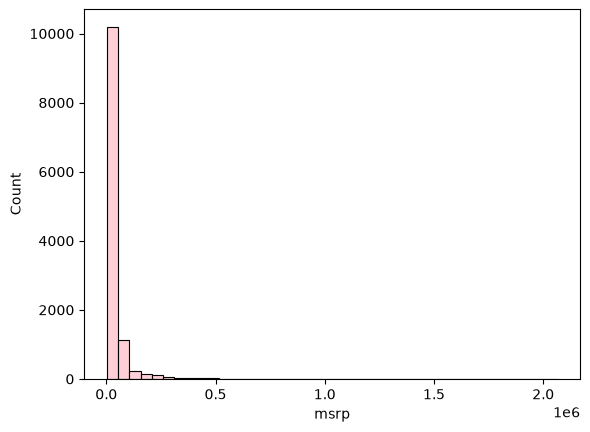

In [5]:
sns.histplot(df.msrp, bins=40, color='pink')


<Axes: xlabel='msrp', ylabel='Count'>

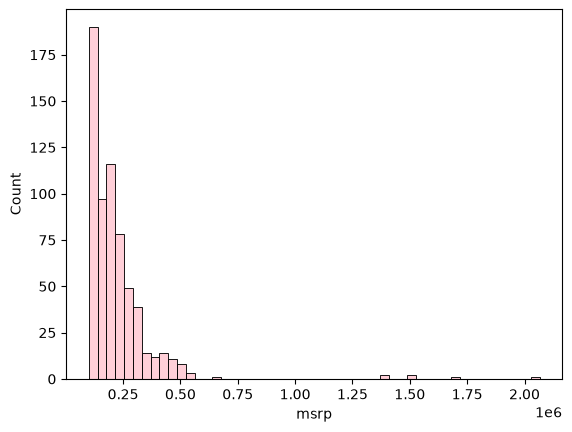

In [6]:
#посмотрим на значения больше 300_000
sns.histplot(df.msrp[df.msrp > 100_000])

<Axes: xlabel='msrp', ylabel='Count'>

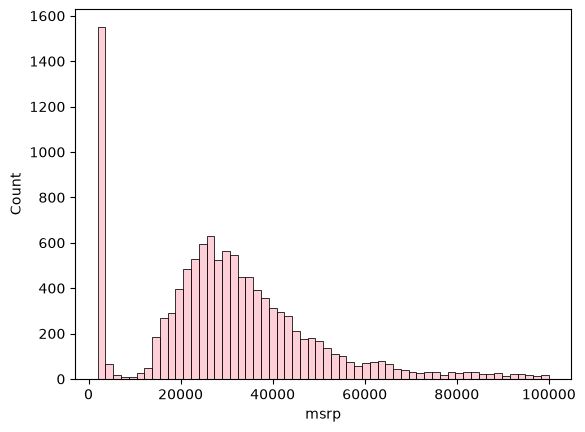

In [7]:
#посмотрим на значения меньше 100_000
sns.histplot(df.msrp[df.msrp < 100_000])

_Так как разброс данных очень большой, мы изменим их масштаб. С помощью логарифма, так как он сжимает большие значения._

<Axes: xlabel='msrp', ylabel='Count'>

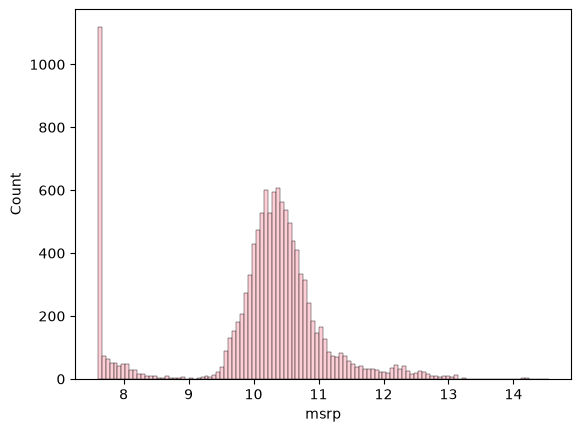

In [8]:
log_price = np.log1p(df.msrp)
sns.histplot(log_price)

_Посмотрим на пропущенные значения._

In [9]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

## _Разделим данные на: обучение, проверка, тест._

In [10]:
n = len(df)

#кол-во строк каждой части
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

#возьмем индексы и перемешаем их
np.random.seed(2)
idx = np.arange(n)
np.random.shuffle(idx)

#перемешанный датафрейм
df_shuf = df.iloc[idx]

#возьмем части
df_tr = df_shuf.iloc[:n_train].copy()
df_val = df_shuf.iloc[n_train:n_train+n_val].copy()
df_test = df_shuf.iloc[n_train+n_val:].copy()

## _Изменим масштаб таргета._

In [11]:
y_tr = np.log1p(df_tr.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

del df_tr['msrp']
del df_val['msrp']
del df_test['msrp']

## _Получим веса с помощью нормального уравнения._

In [12]:
def train_lin_reg(X, y):
    #единицы
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    #нормальное уравнение
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

_Выберем только числовые признаки._

In [13]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg',
 'popularity']

_Теперь возьмем только числовые признаки, заполним в них пропуски и сделаем их numpy массивом._

In [14]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

_Подготовим признаки, узнаем веса с помощью нормального уравнения._

In [15]:
X_train = prepare_X(df_tr)
w_0, w = train_lin_reg(X_train, y_tr)

_Узнаем предсказания._

In [16]:
y_pred = w_0 + X_train.dot(w)

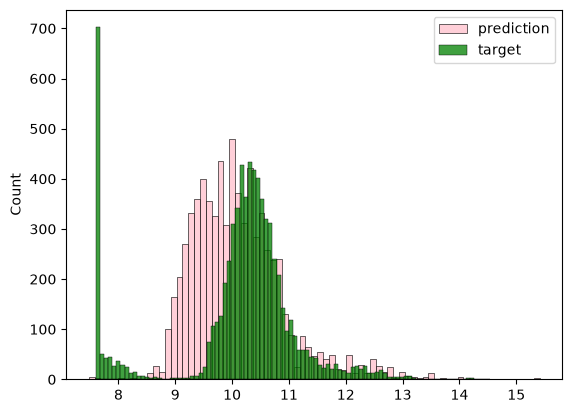

In [17]:
sns.histplot(y_pred, label='prediction')
sns.histplot(y_tr, label='target', color='green')
plt.legend()

_Узнаем среднеквадратическую ошибку._

In [18]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

print('ошибка трейна', rmse(y_tr, y_pred))

ошибка трейна 0.7554192603920132


_Сделаем тоже самое с валидационной выборкой._

In [19]:
X_val = prepare_X(df_val)
#узнаем предсказание с полученными ранне весами
y_pred_val = w_0 + X_val.dot(w)
#узнаем ошибку
print('ошибка валидации',rmse(y_pred_val, y_val))

ошибка валидации 0.7616530991301627


## **_Добавление возраста машины._**

_Получим из года выпуска автомобиля его возраст. Так как мы знаем, что сейчас 2017 год._

In [20]:
#изменим функцию подготовки данных
def prepare_X(df):
    #копии, чтоб ничего не изменить
    df = df.copy()
    features = base.copy()

    #новый кусочек -=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
    #новый признак
    df['age'] = 2017 - df.year
    #новый численый признак
    features.append('age')
    #-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=

    #возьмем только обработанные нами признаки
    df_num = df[features]
    #заполним пропуски
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

_Посмотрим на результат после добавления признака._

In [21]:
#обучим
x_tr = prepare_X(df_tr)
w_0, w = train_lin_reg(x_tr, y_tr)

#предскажем
x_val = prepare_X(df_val)
y_pred_val = w_0 + x_val.dot(w)
print('вал после добавления возраста', rmse(y_val, y_pred_val))

вал после добавления возраста 0.5172055461058327


_Визуализируем результат. И увидим насколько стало лучше._

<Axes: ylabel='Count'>

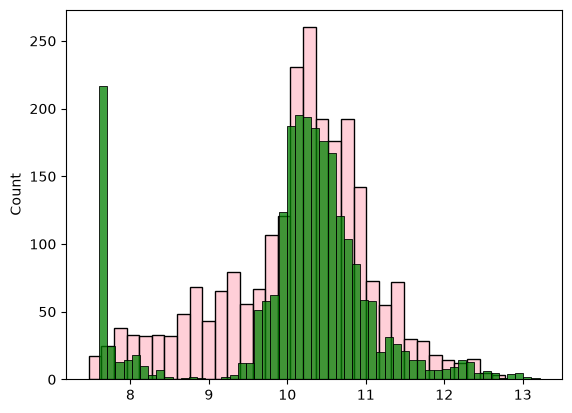

In [22]:
sns.histplot(y_pred_val, label='predict', color='pink')
sns.histplot(y_val, label='target', color='green')

## **_Обработка категориальной переменной кол-ва дверей._**

In [23]:
#снова изменим функцию подготовки данных
def prepare_X(df):
    #копии, чтоб ничего не изменить
    df = df.copy()
    features = base.copy()

    #новый признак
    df['age'] = 2017 - df.year
    #новый численый признак
    features.append('age')
    #новый кусочек -=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
    for v in [2, 3, 4]:
        feature = f'num_doors_{v}s'
        value = (df['number_of_doors'] == v).astype(int)
        df[features] = value
        features.append(feature)
    #-=-=-=-=-=-==-=-=-=-=--=-=-=-=-=-=-=-=-=-=-=-=-=
    #возьмем только нужные нам признаки
    df_num = df[features]
    #заполним пропуски
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

## **_Обработка категориальной переменной марки автомобиля._**

_Мы возьмем только первые пять популярных марок. Все прочие будут для нас - ни одна из популярных пяти._

In [24]:
#снова изменим функцию подготовки данных
def prepare_X(df):
    #копии, чтоб ничего не изменить
    df = df.copy()
    features = base.copy()

    #новый признак
    df['age'] = 2017 - df.year
    #новый численый признак
    features.append('age')

    #обработка дверей
    for v in [2, 3, 4]:
        #название
        feature = f'num_doors_{v}s'
        #столбец булевых значений 0-1
        value = (df['number_of_doors'] == v).astype(int)
        df[feature] = value
        features.append(feature)

    #новый кусочек -=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=
    for v in ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']:
        feature = f'is_make{v}'
        df[feature] = (df['make'] == v).astype(int)
        features.append(feature)
    #-=-=-=-=-=-==-=-=-=-=--=-=-=-=-=-=-=-=-=-=-=-=-=

    #возьмем только нужные нам признаки
    df_num = df[features]
    #заполним пропуски
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

_Узнаем стало ли лучше?_

In [25]:
#обучим
w_0, w = train_lin_reg(prepare_X(df_tr), y_tr)

#оценим
y_pred_val = prepare_X(df_val).dot(w) + w_0
print('после кодирования марки:', rmse(y_val, y_pred_val))

после кодирования марки: 0.5076038849556633


_Проведем one-hot-encoding с ещё несколькими признаками._

In [26]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    #возраст
    df['age'] = 2017 - df.year
    features.append('age')

    #двери
    for v in [2, 3, 4]:
        feature = f'num_doors_{v}'
        df[feature] = (df['number_of_doors'] == v).astype(int)
        features.append(feature)

    #марка
    for v in ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']:
        feature = f'is_make_{v}'
        df[feature] = (df['make'] == v).astype(int)
        features.append(feature)

    #тип топлива
    for v in ['regular_unleaded', 'premium_unleaded_(required)',
              'premium_unleaded_(recommended)', 'flex-fuel_(unleaded/e85)']:
        feature = f'is_type_{v}'
        df[feature] = (df['engine_fuel_type'] == v).astype(int)
        features.append(feature)

    #тип трансмисии
    for v in ['automatic', 'manual', 'automated_manual']:
        feature = f'is_transmission_{v}'
        df[feature] = (df['transmission_type'] == v).astype(int)
        features.append(feature)

    #тип привода
    for v in ['front_wheel_drive', 'rear_wheel_drive', 'all_wheel_drive', 'four_wheel_drive']:
        feature = f'is_driven_wheens_{v}'
        df[feature] = (df['driven_wheels'] == v).astype(int)
        features.append(feature)

    #категорию маркетинга
    for v in ['crossover', 'flex_fuel', 'luxury', 'luxury,performance', 'hatchback']:
        feature = f'is_mc_{v}'
        df[feature] = (df['market_category'] == v).astype(int)
        features.append(feature)

    #размер
    for v in ['compact', 'midsize', 'large']:
        feature = f'is_size_{v}'
        df[feature] = (df['vehicle_size'] == v).astype(int)
        features.append(feature)

    #стиль
    for v in ['sedan', '4dr_suv', 'coupe', 'convertible', '4dr_hatchback']:
        feature = f'is_style_{v}'
        df[feature] = (df['vehicle_style'] == v).astype(int)
        features.append(feature)

    #возьмем только числовые
    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

_Проверим результат._

In [27]:
#обучим
X_train = prepare_X(df_tr)
w_0, w = train_lin_reg(X_train, y_tr)

#проверим
X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation:', rmse(y_val, y_pred))

validation: 118.50015319162071


_Видим, что стало хуже. Посмотри на w0 и увидим, что вес стал очень большим._

In [28]:
print(f'{w_0:.0f}')

-10946145057342842


### **Регуляризация.**

$$w = (X^T X + \alpha I)^{-1}X^T y$$

_I — единичная матрица, которая представляет собой матрицу с единицами на главной диагонали и нулями в остальных
случаях. Мы умножаем эту единичную матрицу на число α. Таким образом, все
значения, находящиеся на диагонали I, становятся α._

In [36]:
def tr_regular(x, y, r=0.0):
    #свободный коэф
    ones = np.ones(x.shape[0])
    x = np.column_stack([ones, x])

    #добавление r к основной диагонали
    xtx = x.T.dot(x)
    reg = r * np.eye(xtx.shape[0])
    xtx = xtx + reg

    #
    xtx_inv = np.linalg.inv(xtx)
    w = xtx_inv.dot(x.T).dot(y)

    return w[0], w[1:]

_Посмотрим, как теперь меняются веса после регуляризации._

In [34]:
for r in [0, 0.001, 0.01, 0.1, 1, 10]:
    w_0, w = tr_regular(X_train, y_tr, r = r)
    print(f'{w_0:.2f}', f'{w[13]:.2f}')

-10946145057342842.00 -14.40
7.20 -0.10
7.18 -0.10
7.05 -0.10
6.22 -0.10
4.39 -0.09


_Проверим помогла ли регуляризация._

In [37]:
#обучим
X_train = prepare_X(df_tr)
w_0, w = tr_regular(X_train, y_tr, 0.001)

#проверим
X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('reg_val:', rmse(y_val, y_pred))

reg_val: 0.46022676169145377
